<a href="https://colab.research.google.com/github/salmangeo/jupyter_notebooks/blob/main/mat_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pygbif pandas geopandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.0/70.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Example 3 plants
plants_df = pd.DataFrame({
    "plant_name": ["Bougainvillea glabra",
                   "Prosopis juliflora",
                   "Syzygium cumini",
                   "Holoptelea integrifolia",
                   "Emblica officinalis",
                   "Diospyros melanoxylon" ,
                   "Morus alba",
                   "Lagerstroemia parviflora",
                   "Schleichera oleosa",
                   "Barringtonia acutangula",
                   "Clerodendrum inerme",
                   "Melastoma malabathricum",
                   "Ziziphus mauritiana",
                   "Xanthium strumarium",
                   "Stellaria media",
                   "Solanum tuberosum",
                   "Euphorbia hirta",
                   "Andrographis paniculata",
                   "Rungia pectinata",
                   "Hibiscus rosa-sinensis",
                   "Cannabis sativa",
                   "Ipomoea carnea",
                   "Typha angustifolia",
                   "Myriophyllum aquaticum",
                   "Nymphaea pubescens",
                   "Polygonum plebeium",
                   "Madhuca longifolia",
                    "Bombax ceiba"
                    "Mangifera indica",
                    "Azadirachta indica",
                    "Terminalia arjuna",
                    "Ficus benghalensis",
                    "Acacia nilotica" ]
})

print(plants_df)


                      plant_name
0           Bougainvillea glabra
1             Prosopis juliflora
2                Syzygium cumini
3        Holoptelea integrifolia
4            Emblica officinalis
5          Diospyros melanoxylon
6                     Morus alba
7       Lagerstroemia parviflora
8             Schleichera oleosa
9        Barringtonia acutangula
10           Clerodendrum inerme
11       Melastoma malabathricum
12           Ziziphus mauritiana
13           Xanthium strumarium
14               Stellaria media
15             Solanum tuberosum
16               Euphorbia hirta
17       Andrographis paniculata
18              Rungia pectinata
19        Hibiscus rosa-sinensis
20               Cannabis sativa
21                Ipomoea carnea
22            Typha angustifolia
23        Myriophyllum aquaticum
24            Nymphaea pubescens
25            Polygonum plebeium
26            Madhuca longifolia
27  Bombax ceibaMangifera indica
28            Azadirachta indica
29        

In [ ]:
import pandas as pd

# Example 3 plants
plants_df_next = pd.DataFrame({
    "plant_name": [ "Madhuca longifolia",
                    "Bombax ceiba"
                    "Mangifera indica",
                    "Azadirachta indica",
                    "Terminalia arjuna",
                    "Ficus benghalensis",
                    "Acacia nilotica" ]
})

print(plants_df_next)


                     plant_name
0            Madhuca longifolia
1  Bombax ceibaMangifera indica
2            Azadirachta indica
3             Terminalia arjuna
4            Ficus benghalensis
5               Acacia nilotica


In [ ]:
from pygbif import occurrences
import pandas as pd

def get_gbif_occurrences(
    species,
    limit=500,
    country=None,
    lat_min=None,
    lat_max=None,
    lon_min=None,
    lon_max=None,
    elev_min=None,
    elev_max=None
):
    """
    Fetch GBIF occurrence records for a species with optional filters:
    - country: ISO 2-letter country code (e.g., 'IN', 'NP', 'PK')
    - lat_min, lat_max, lon_min, lon_max: bounding box
    - elev_min, elev_max: elevation limits (meters)
    """
    search_params = dict(scientificName=species, limit=limit, hasCoordinate=True)

    # Add filters if provided
    if country:
        search_params["country"] = country
    if lat_min is not None:
        search_params["decimalLatitude"] = f"{lat_min},{lat_max}"
    if lon_min is not None:
        search_params["decimalLongitude"] = f"{lon_min},{lon_max}"
    if elev_min is not None:
        search_params["elevation"] = f"{elev_min},{elev_max}"

    res = occurrences.search(**search_params)
    if 'results' not in res:
        return pd.DataFrame()

    data = [
        {
            "species": species,
            "lat": r.get("decimalLatitude"),
            "lon": r.get("decimalLongitude"),
            "country": r.get("country"),
            "elevation": r.get("elevation"),
            "eventDate": r.get("eventDate")
        }
        for r in res['results']
        if r.get("decimalLatitude") and r.get("decimalLongitude")
    ]

    return pd.DataFrame(data)


In [ ]:
import time

In [ ]:
all_occurrences

,species,lat,lon,country,elevation,eventDate,geometry
0,Bougainvillea glabra,27.504384,89.878458,Bhutan,1386.00,2022-07-28T04:54:45.314Z,POINT (89.878458 27.504384)
1,Bougainvillea glabra,27.024819,90.122831,Bhutan,1409.00,2021-08-30T02:37:55.063Z,POINT (90.122831 27.024819)
2,Bougainvillea glabra,27.080442,88.484638,India,1313.35,2020-03-09T07:38:06.833Z,POINT (88.484638 27.080442)
3,Bougainvillea glabra,26.622222,101.586111,China,1613.00,2010-07-11T00:00,POINT (101.586111 26.622222)
4,Bougainvillea glabra,27.300000,87.570000,Nepal,1463.00,1971-12-17,POINT (87.57 27.3)
...,...,...,...,...,...,...,...
236,Acacia nilotica,10.616667,13.600000,Cameroon,1000.00,1972-10-09,POINT (13.6 10.616667)
237,Acacia nilotica,8.666667,39.166667,Ethiopia,1600.00,1972-10-29T00:00,POINT (39.166667 8.666667)
238,Acacia nilotica,9.066667,42.383333,Ethiopia,1520.00,1962-11-02T00:00,POINT (42.383333 9.066667)
239,Acacia nilotica,9.516667,41.416667,Ethiopia,1100.00,1961-08-24T00:00,POINT (41.416667 9.516667)


In [ ]:
plants_df_next

,plant_name
0,Madhuca longifolia
1,Bombax ceibaMangifera indica
2,Azadirachta indica
3,Terminalia arjuna
4,Ficus benghalensis
5,Acacia nilotica


In [ ]:
# Define your area of interest and elevation limits once
LAT_MIN, LAT_MAX = 8, 30
LON_MIN, LON_MAX = 10, 150
ELEV_MIN, ELEV_MAX = 1000, 3000

# Empty DataFrame to store all results
all_occurrences = pd.DataFrame()

# Loop over all plant names
for plant in plants_df_next["plant_name"]:
    print(f"Fetching GBIF data for {plant}...")
    occ_df = get_gbif_occurrences(
        plant,
        lat_min=LAT_MIN,
        lat_max=LAT_MAX,
        lon_min=LON_MIN,
        lon_max=LON_MAX,
        elev_min=ELEV_MIN,
        elev_max=ELEV_MAX,
        limit=100
    )
    all_occurrences = pd.concat([all_occurrences, occ_df], ignore_index=True)
    time.sleep(1)  # To avoid hitting the API too hard


print("✅ Done! Total records collected:", len(all_occurrences))
print(all_occurrences.head())


Fetching GBIF data for Madhuca longifolia...
Fetching GBIF data for Bombax ceibaMangifera indica...
Fetching GBIF data for Azadirachta indica...
Fetching GBIF data for Terminalia arjuna...
Fetching GBIF data for Ficus benghalensis...
Fetching GBIF data for Acacia nilotica...
✅ Done! Total records collected: 15
              species        lat        lon       country  elevation  \
0  Azadirachta indica  27.618165  89.838240        Bhutan    1195.10   
1  Ficus benghalensis  25.149276  73.580582         India    1037.00   
2  Ficus benghalensis  27.585617  89.863806        Bhutan    1206.33   
3     Acacia nilotica  18.106361  42.702569  Saudi Arabia    2172.00   
4     Acacia nilotica   9.546626  44.047250       Somalia    1300.00   

                  eventDate  
0  2022-07-23T08:11:40.821Z  
1      2025-04-09T04:35:14Z  
2  2022-10-22T08:46:20.802Z  
3      2024-07-03T17:36:03Z  
4                2016-10-20  


In [ ]:
all_occurrences

,species,lat,lon,country,elevation,eventDate
0,Bougainvillea glabra,27.504384,89.878458,Bhutan,1386.00,2022-07-28T04:54:45.314Z
1,Bougainvillea glabra,27.024819,90.122831,Bhutan,1409.00,2021-08-30T02:37:55.063Z
2,Bougainvillea glabra,27.080442,88.484638,India,1313.35,2020-03-09T07:38:06.833Z
3,Bougainvillea glabra,26.622222,101.586111,China,1613.00,2010-07-11T00:00
4,Bougainvillea glabra,27.300000,87.570000,Nepal,1463.00,1971-12-17
...,...,...,...,...,...,...
98,Polygonum plebeium,25.600000,100.033333,China,1450.00,1984-06-14
99,Polygonum plebeium,25.716667,100.033333,China,2700.00,1984-06-16
100,Polygonum plebeium,25.720000,100.030000,China,2700.00,1984-06-16
101,Polygonum plebeium,25.600000,100.030000,China,1450.00,1984-06-14


In [ ]:
from pygbif import occurrences

def get_gbif_occurrences(species, limit=500):
    """Fetch occurrence records from GBIF for a given species"""
    res = occurrences.search(scientificName=species, limit=limit, hasCoordinate=True)
    if 'results' not in res:
        return pd.DataFrame()

    # Extract lat/lon and keep minimal info
    data = [
        {
            "species": species,
            "lat": r.get("decimalLatitude"),
            "lon": r.get("decimalLongitude"),
            "country": r.get("country"),
            "eventDate": r.get("eventDate")
        }
        for r in res['results']
        if r.get("decimalLatitude") and r.get("decimalLongitude")
    ]
    return pd.DataFrame(data)

# Example: get another plant_from swti mam table
bougenvillea_df = get_gbif_occurrences("Bougainvillea glabra", limit=300)
print(neem_df.head())


              species        lat         lon country            eventDate
0  Azadirachta indica  10.636880    1.270556   Benin  2025-01-02T08:06:19
1  Azadirachta indica  24.819210 -107.363168  Mexico     2025-01-11T09:51
2  Azadirachta indica  19.372757  -96.374849  Mexico  2025-01-12T17:35:55
3  Azadirachta indica  20.849265  -86.876436  Mexico  2025-01-13T08:11:26
4  Azadirachta indica  25.194328   75.859022   India  2025-01-10T15:36:45


In [ ]:
bougenvillea_df

,species,lat,lon,country,eventDate
0,Bougainvillea glabra,-3.898508,-79.869636,Ecuador,2025-01-01T09:28:36
1,Bougainvillea glabra,-13.402222,-40.702778,Brazil,2025-01-10
2,Bougainvillea glabra,-0.471033,-76.980470,Ecuador,2025-01-23T07:34:43
3,Bougainvillea glabra,-23.152048,-46.858946,Brazil,2025-01-11T18:02:58Z
4,Bougainvillea glabra,-15.847457,-48.943764,Brazil,2025-01-04T14:27:38Z
...,...,...,...,...,...
295,Bougainvillea glabra,12.300150,76.689091,India,2023-07-24T10:19
296,Bougainvillea glabra,9.883477,-83.626862,Costa Rica,2023-07-22T17:21:29
297,Bougainvillea glabra,-15.832047,-47.819824,Brazil,2023-07-30T13:32
298,Bougainvillea glabra,37.746643,-25.669849,Portugal,2023-07-30T20:13:39Z


In [ ]:
all_occurrences = pd.DataFrame()

for plant in plants_df["plant_name"]:
    occ_df = get_gbif_occurrences(plant, limit=100)
    all_occurrences = pd.concat([all_occurrences, occ_df], ignore_index=True)

print(all_occurrences.head())
print("Total records collected:", len(all_occurrences))


                species        lat        lon  country             eventDate
0  Bougainvillea glabra  -3.898508 -79.869636  Ecuador   2025-01-01T09:28:36
1  Bougainvillea glabra -13.402222 -40.702778   Brazil            2025-01-10
2  Bougainvillea glabra  -0.471033 -76.980470  Ecuador   2025-01-23T07:34:43
3  Bougainvillea glabra -23.152048 -46.858946   Brazil  2025-01-11T18:02:58Z
4  Bougainvillea glabra -15.847457 -48.943764   Brazil  2025-01-04T14:27:38Z
Total records collected: 2597


In [ ]:
pip install geopandas matplotlib


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Create geometry column from lat/lon
all_occurrences['geometry'] = all_occurrences.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(all_occurrences, geometry='geometry', crs="EPSG:4326")

print(gdf.head())


              species        lat        lon       country  elevation  \
0  Azadirachta indica  27.618165  89.838240        Bhutan    1195.10   
1  Ficus benghalensis  25.149276  73.580582         India    1037.00   
2  Ficus benghalensis  27.585617  89.863806        Bhutan    1206.33   
3     Acacia nilotica  18.106361  42.702569  Saudi Arabia    2172.00   
4     Acacia nilotica   9.546626  44.047250       Somalia    1300.00   

                  eventDate                   geometry  
0  2022-07-23T08:11:40.821Z  POINT (89.83824 27.61816)  
1      2025-04-09T04:35:14Z  POINT (73.58058 25.14928)  
2  2022-10-22T08:46:20.802Z  POINT (89.86381 27.58562)  
3      2024-07-03T17:36:03Z  POINT (42.70257 18.10636)  
4                2016-10-20   POINT (44.04725 9.54663)  


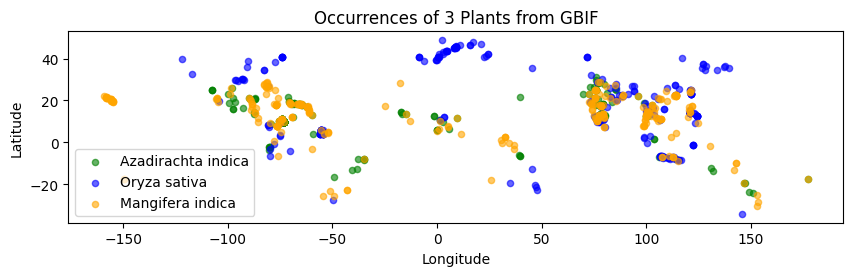

In [ ]:
# Plot by species
fig, ax = plt.subplots(figsize=(10, 8))
species_list = gdf['species'].unique()

colors = ['green', 'blue', 'orange']  # one color per species

for i, sp in enumerate(species_list):
    gdf[gdf['species'] == sp].plot(ax=ax, markersize=20, color=colors[i], label=sp, alpha=0.6)

ax.set_title("Occurrences of 3 Plants from GBIF")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()


In [ ]:
# Remove invalid lat/lon
gdf = gdf[(gdf['lat'] != 0) & (gdf['lon'] != 0)]

# If available: remove high uncertainty records (coordinateUncertaintyInMeters)
if 'coordinateUncertaintyInMeters' in gdf.columns:
    gdf = gdf[gdf['coordinateUncertaintyInMeters'] <= 5000]

print(f"Records after cleaning: {len(gdf)}")


Records after cleaning: 15


In [ ]:
gdf

,species,lat,lon,country,elevation,eventDate,geometry,annual_prec,annual_tmin,annual_tmax
0,Bougainvillea glabra,27.504384,89.878458,Bhutan,1386.00,2022-07-28T04:54:45.314Z,POINT (89.87846 27.50438),1168,2.941250,26.392750
1,Bougainvillea glabra,27.024819,90.122831,Bhutan,1409.00,2021-08-30T02:37:55.063Z,POINT (90.12283 27.02482),2043,7.472250,27.283501
2,Bougainvillea glabra,27.080442,88.484638,India,1313.35,2020-03-09T07:38:06.833Z,POINT (88.48464 27.08044),3417,9.736500,28.808500
3,Bougainvillea glabra,26.622222,101.586111,China,1613.00,2010-07-11T00:00,POINT (101.58611 26.62222),780,4.742250,29.826500
4,Bougainvillea glabra,27.300000,87.570000,Nepal,1463.00,1971-12-17,POINT (87.57 27.3),1843,4.401250,25.046749
...,...,...,...,...,...,...,...,...,...,...
341,Acacia nilotica,10.616667,13.600000,Cameroon,1000.00,1972-10-09,POINT (13.6 10.61667),947,13.300000,34.598999
342,Acacia nilotica,8.666667,39.166667,Ethiopia,1600.00,1972-10-29T00:00,POINT (39.16667 8.66667),963,7.873750,26.263000
343,Acacia nilotica,9.066667,42.383333,Ethiopia,1520.00,1962-11-02T00:00,POINT (42.38333 9.06667),638,11.129250,29.293501
344,Acacia nilotica,9.516667,41.416667,Ethiopia,1100.00,1961-08-24T00:00,POINT (41.41667 9.51667),596,14.331500,35.334499


In [ ]:
pip install rasterio

In [ ]:
import rasterio
import numpy as np
import glob

def extract_raster_values(points_gdf, raster_folder, variable_name):
    """Extract values from all monthly raster files and return annual min/max/total"""
    rasters = sorted(glob.glob(f"{raster_folder}/*.tif"))
    all_values = []

    for r in rasters:
        with rasterio.open(r) as src:
            coords = [(x,y) for x, y in zip(points_gdf['lon'], points_gdf['lat'])]
            vals = [v[0] if v is not None else np.nan
                    for v in src.sample(coords)]
            all_values.append(vals)

    # Convert to numpy array (points x months)
    arr = np.array(all_values).T  # shape: n_points x 12 months

    if variable_name in ['tmin', 'tmax']:
        # Annual min/max
        return np.min(arr, axis=1) if variable_name=='tmin' else np.max(arr, axis=1)
    elif variable_name=='prec':
        # Annual total precipitation
        return np.sum(arr, axis=1)

# Example: extract tmin, tmax, prec

gdf['annual_prec'] = extract_raster_values(gdf, "sample_data/prec", "prec")
gdf['annual_tmin'] = extract_raster_values(gdf, "sample_data/tmin", "tmin")
gdf['annual_tmax'] = extract_raster_values(gdf, "sample_data/tmax", "tmax")
print(gdf.head())


              species        lat        lon       country  elevation  \
0  Azadirachta indica  27.618165  89.838240        Bhutan    1195.10   
1  Ficus benghalensis  25.149276  73.580582         India    1037.00   
2  Ficus benghalensis  27.585617  89.863806        Bhutan    1206.33   
3     Acacia nilotica  18.106361  42.702569  Saudi Arabia    2172.00   
4     Acacia nilotica   9.546626  44.047250       Somalia    1300.00   

                  eventDate                   geometry  annual_prec  \
0  2022-07-23T08:11:40.821Z  POINT (89.83824 27.61816)         1168   
1      2025-04-09T04:35:14Z  POINT (73.58058 25.14928)          718   
2  2022-10-22T08:46:20.802Z  POINT (89.86381 27.58562)         1168   
3      2024-07-03T17:36:03Z  POINT (42.70257 18.10636)          229   
4                2016-10-20   POINT (44.04725 9.54663)          422   

   annual_tmin  annual_tmax  
0      2.94125    26.392750  
1      8.06675    36.465752  
2      2.94125    26.392750  
3      7.74650    32

In [ ]:
survival_df.to_csv("survival_summary_pop.csv", index=False)

In [ ]:
survival_summary = []

for sp in gdf['species'].unique():
    df_sp = gdf[gdf['species']==sp]
    tmin_low = np.percentile(df_sp['annual_tmin'], 5)
    tmax_high = np.percentile(df_sp['annual_tmax'], 95)
    prec_low = np.percentile(df_sp['annual_prec'], 5)
    prec_high = np.percentile(df_sp['annual_prec'], 95)

    survival_summary.append({
        "species": sp,
        "annual_tmin_5th": tmin_low,
        "annual_tmax_95th": tmax_high,
        "annual_prec_5th": prec_low,
        "annual_prec_95th": prec_high,
        "n_points": len(df_sp)
    })

survival_df = pd.DataFrame(survival_summary)
print(survival_df)


              species  annual_tmin_5th  annual_tmax_95th  annual_prec_5th  \
0  Azadirachta indica         2.941250         26.392750           1168.0   
1  Ficus benghalensis         3.197525         35.962101            740.5   
2     Acacia nilotica         7.816488         36.801239            184.0   

   annual_prec_95th  n_points  
0            1168.0         1  
1            1145.5         2  
2             954.2        12  


In [ ]:
survival_summary_new

In [ ]:
survival_df

,species,annual_tmin_5th,annual_tmax_95th,annual_prec_5th,annual_prec_95th,n_points
0,Bougainvillea glabra,3.233250e+00,29.622900,857.60,3142.20,5
1,Prosopis juliflora,1.275229e+01,32.682713,359.40,618.60,2
2,Syzygium cumini,-8.774998e-01,39.384148,968.20,2571.40,9
3,Emblica officinalis,-6.325001e-02,32.015129,996.25,2305.00,26
4,Morus alba,-1.003280e+01,30.351646,676.20,2286.80,25
5,Lagerstroemia parviflora,1.362200e+01,29.764250,1639.00,1639.00,1
6,Schleichera oleosa,1.362200e+01,29.764250,1639.00,1639.00,1
7,Barringtonia acutangula,1.906825e+01,29.960751,2530.00,2530.00,1
8,Melastoma malabathricum,2.150687e+00,30.847725,1143.90,3340.15,30
9,Ziziphus mauritiana,-3.552500e-01,39.131622,533.00,1386.00,11


In [ ]:
survival_df.to_csv("survival_summary_new.csv", index=False)

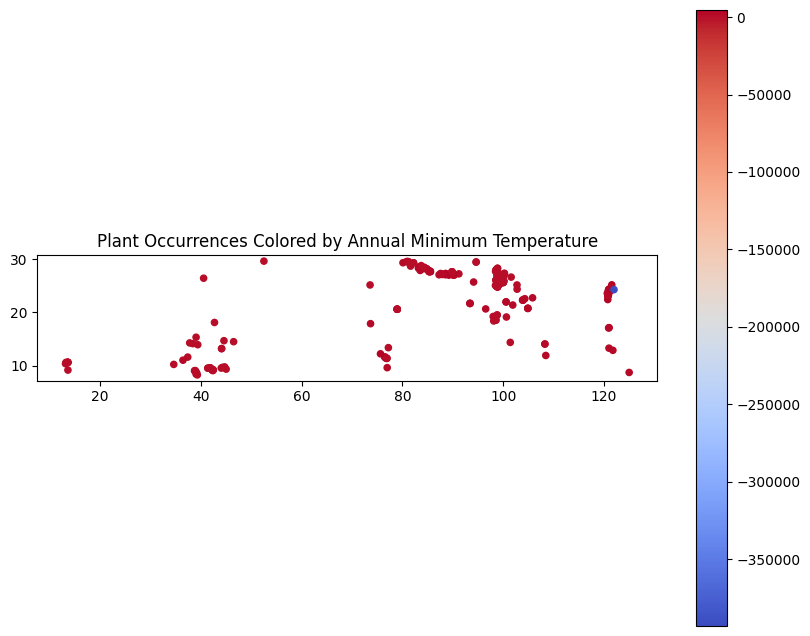

In [ ]:
import matplotlib.pyplot as plt

# Plot by species

fig, ax = plt.subplots(figsize=(10,8))
gdf.plot(ax=ax, column='annual_prec', cmap='coolwarm', legend=True, markersize=20)
plt.title("Plant Occurrences Colored by Annual Minimum Temperature")
plt.show()

In [ ]:
df_taxa = pd.read_excel("sample_data/data/taxa_count_kanwar.xlsx")
print(df_taxa.head())

                      taxa      sid1      sid2      sid3      sid4      sid5  \
0     Bougainvillea glabra  0.000000  0.320513  0.299401  1.470588  0.666667   
1       Prosopis juliflora  0.000000  0.320513  0.598802  0.294118  0.666667   
2          Syzygium cumini  0.440529  0.320513  0.000000  0.588235  0.333333   
3  Holoptelea integrifolia  0.000000  0.320513  0.299401  0.294118  0.333333   
4      Emblica officinalis  0.000000  0.000000  0.299401  0.588235  0.333333   

       sid6      sid7      sid8      sid9  ...     sid62     sid63  sid64  \
0  0.336700  1.587302  0.421941  0.729927  ...  2.109705  1.162791  1.250   
1  1.010101  0.634921  1.687764  0.729927  ...  1.265823  2.325581  1.875   
2  0.673401  0.634921  0.421941  0.729927  ...  0.421941  0.000000  0.625   
3  0.336700  0.634921  0.843882  0.729927  ...  0.000000  0.000000  0.000   
4  0.673401  0.634921  1.265823  1.459854  ...  0.421941  1.162791  1.250   

      sid65     sid66     sid67     sid68     sid69     

In [ ]:
survival_df

,species,annual_tmin_5th,annual_tmax_95th,annual_temp_5th,annual_temp_95th,n_points
0,Bougainvillea glabra,5.837790,38.005035,210.20,2744.20,100
1,Prosopis juliflora,6.337500,41.924599,113.60,1561.00,100
2,Syzygium cumini,8.532837,41.453175,660.85,2591.95,100
3,Holoptelea integrifolia,7.386750,42.395248,607.00,1595.35,100
4,Emblica officinalis,8.797000,41.618252,610.65,3402.65,100
5,Diospyros melanoxylon,9.328213,42.781349,698.35,1862.30,100
6,Morus alba,-10.231750,34.640846,499.15,2072.00,100
7,Lagerstroemia parviflora,6.277425,41.690361,735.40,3698.00,100
8,Schleichera oleosa,9.172750,40.654362,1024.15,4190.45,100
9,Barringtonia acutangula,11.597647,38.603951,867.90,2950.15,100


In [ ]:
def get_strict_coa_survival_v2(taxa_row, climate_db,
                               temp_range_thresh=20, precip_range_thresh=2000,
                               temp_max_abs=35, precip_max_abs=4000,
                               temp_min_range=1, precip_min_range=10):
    # Find present taxa (those occurring above 0)
    present_taxa = taxa_row[taxa_row > 0].index
    # Match species names between taxa and climate DB (assuming "species" and "taxa" columns)
    relevant_climate = climate_db[climate_db['species'].isin(present_taxa)].set_index('species')

    if relevant_climate.empty:
        return pd.Series([None, None, None, None],
                         index=["MAT_lower", "MAT_upper", "MAP_lower", "MAP_upper"])

    # Adapt column names for temperature and precipitation thresholds
    climate_filtered = relevant_climate[
        (relevant_climate["annual_tmax_95th"] - relevant_climate["annual_tmin_5th"] <= temp_range_thresh) &
        (relevant_climate["annual_temp_95th"] - relevant_climate["annual_temp_5th"] <= precip_range_thresh) &
        (relevant_climate["annual_tmax_95th"] <= temp_max_abs) &
        (relevant_climate["annual_temp_95th"] <= precip_max_abs) &
        ((relevant_climate["annual_tmax_95th"] - relevant_climate["annual_tmin_5th"]) >= temp_min_range) &
        ((relevant_climate["annual_temp_95th"] - relevant_climate["annual_temp_5th"]) >= precip_min_range)
    ]

    if climate_filtered.empty:
        return pd.Series([None, None, None, None],
                         index=["MAT_lower", "MAT_upper", "MAP_lower", "MAP_upper"])

    # Calculate CoA overlaps
    MAT_lower = climate_filtered["annual_tmin_5th"].max()
    MAT_upper = climate_filtered["annual_tmax_95th"].min()
    MAP_lower = climate_filtered["annual_temp_5th"].max()
    MAP_upper = climate_filtered["annual_temp_95th"].min()

    if MAT_lower > MAT_upper or MAP_lower > MAP_upper:
        return pd.Series([None, None, None, None],
                         index=["MAT_lower", "MAT_upper", "MAP_lower", "MAP_upper"])

    return pd.Series([MAT_lower, MAT_upper, MAP_lower, MAP_upper],
                     index=["MAT_lower", "MAT_upper", "MAP_lower", "MAP_upper"])


In [ ]:
result_df = df_taxa.apply(
    lambda row: get_strict_coa_survival_v2(row.iloc[1:], survival_df), axis=1)


In [ ]:
result_df

,MAT_lower,MAT_upper,MAP_lower,MAP_upper
0,None,None,None,None
1,None,None,None,None
2,None,None,None,None
3,None,None,None,None
4,None,None,None,None
5,None,None,None,None
6,None,None,None,None
7,None,None,None,None
8,None,None,None,None
9,None,None,None,None
